In [5]:
'''
This file is a demonstration of the different types of behaviour exhibited by a simple neuron
model with autapse.

'''


import aqua
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.stimulus import *
from aqua.plotting_functions import *
from aqua.utils import *

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec

In [ ]:
# RS integrator
RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 0., 'tau': 2.}


In [7]:

# Only consider 2 neuron models... 1 below chaos, 1 in chaos...
f_vals = np.array([0, 250, 400, 450])
I_HEIGHT = 60

T = 10000
dt = 0.1
N_iter = int(T/dt)

N_neurons = len(f_vals)

I_inj = I_HEIGHT * np.ones((N_neurons, N_iter))


params = []

for n, f in enumerate(f_vals):
    temp = RS.copy()
    temp['f'] = f
    params.append(temp)     # appended twice

df = pd.DataFrame(params)

x_start = np.full((N_neurons, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(N_neurons)

batch = batchAQUA(params)
batch.Initialise(x_start, t_start)

X, t, spikes = batch.update_batch(dt, N_iter, I_inj)



100%|██████████| 99999/99999 [00:12<00:00, 8049.44it/s]


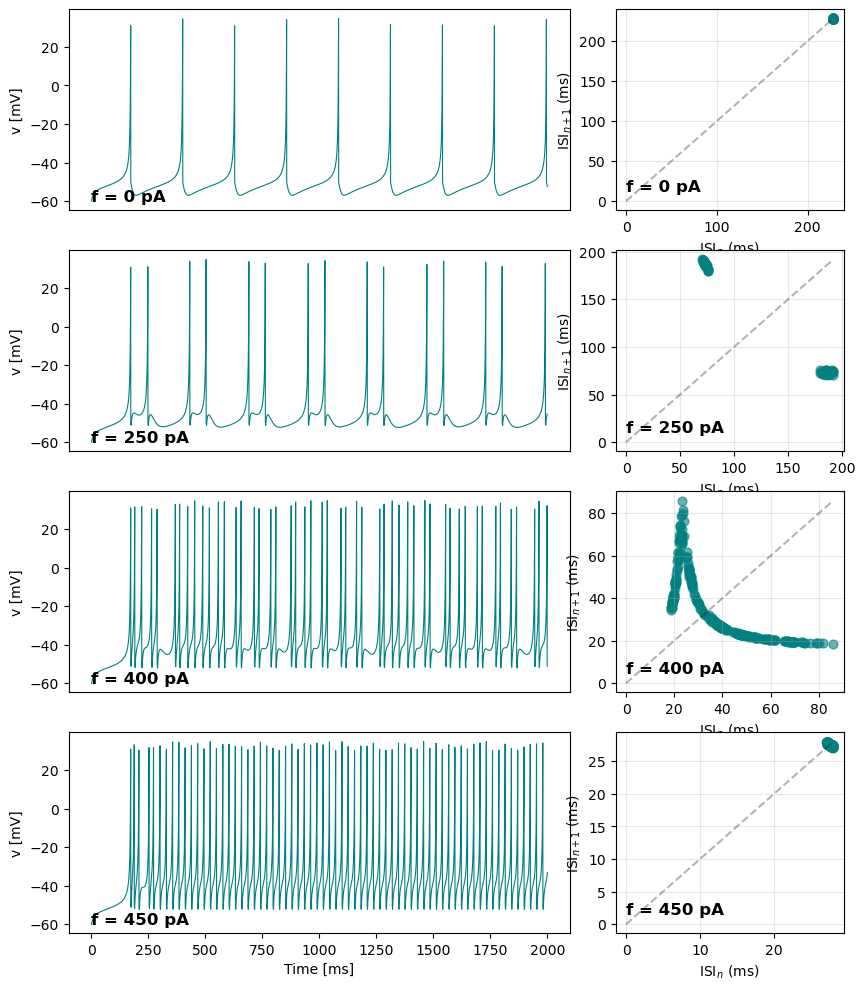

In [ ]:
fig = plt.figure(figsize=(10, 3 * N_neurons))
gs = gridspec.GridSpec(N_neurons, 3, figure=fig)
#split = np.arange(15000, 70000, 1)     # 2000-5000 ms
split = np.arange(0, 20000)
for n, f in enumerate(df['f']):
    # 1. Membrane Potential Axis (Spans columns 0 and 1)
    ax_vm = fig.add_subplot(gs[n, 0:2])
    ax_vm.plot(t[split], X[n, 0, split], color='teal', lw=0.8)
    #ax_vm.set_title(f"f = {f}: Membrane Potential")
    ax_vm.text(0, -60, f'f = {f} pA', fontsize = 'large', fontweight = 'bold')
    if n != len(df['f'])-1:
        ax_vm.set_xticks([])
    else:
        ax_vm.set_xlabel('Time [ms]')

    ax_vm.set_ylabel("v [mV]")
    
    # 2. Return Map Axis (Spans column 2)
    ax_map = fig.add_subplot(gs[n, 2])

    # Use the function we built previously!
    plot_first_return_map(
        spikes[n], 
        burn_in=500, 
        ax=ax_map, 
        c='teal', 
        s=20
    )
    ax_map.text(0, 0.05*ax_map.get_ylim()[1], f'f = {f} pA', fontsize = 'large', fontweight = 'bold')
    ax_map.set_title(f"")

plt.savefig(f"./behaviours_plots/{RS['name']}_compare_membrane_traces.svg")
